In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Importar la base de datos

In [64]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data_raw = pd.read_csv(url)
months_raw = data_raw['Month'].unique()
passengers_raw = data_raw['Passengers']
print(months_raw)
print(passengers_raw)

<StringArray>
['1949-01', '1949-02', '1949-03', '1949-04', '1949-05', '1949-06', '1949-07',
 '1949-08', '1949-09', '1949-10',
 ...
 '1960-03', '1960-04', '1960-05', '1960-06', '1960-07', '1960-08', '1960-09',
 '1960-10', '1960-11', '1960-12']
Length: 144, dtype: str
0      112
1      118
2      132
3      129
4      121
      ... 
139    606
140    508
141    461
142    390
143    432
Name: Passengers, Length: 144, dtype: int64


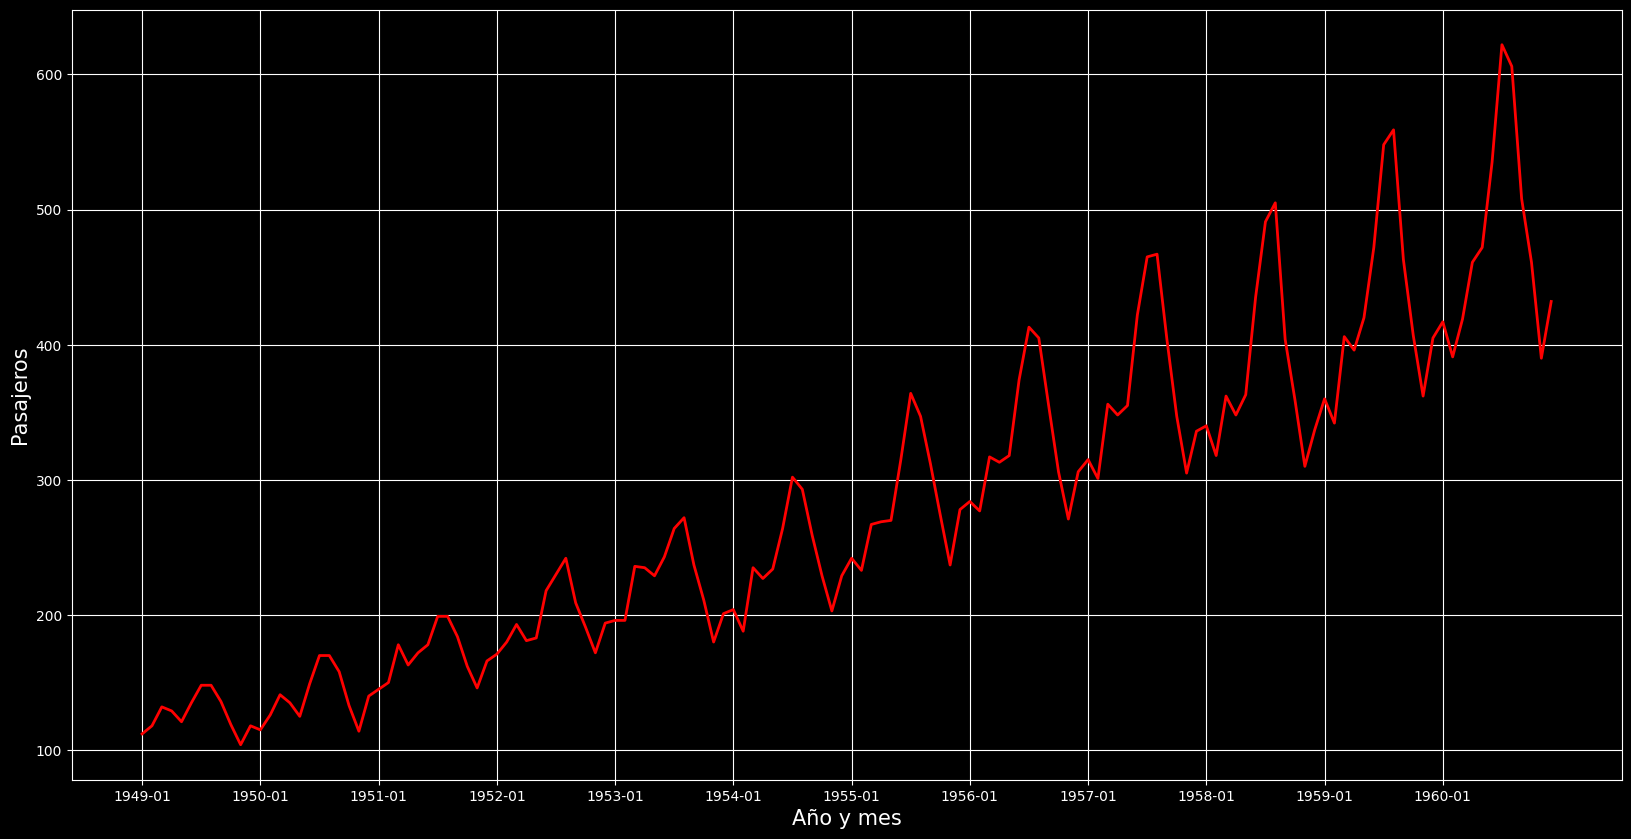

In [65]:
plt.figure(figsize = (20,10))
plt.plot(months_raw, passengers_raw, linewidth = 2, color = 'red')
plt.grid(True)
plt.xticks(months_raw[::12])
plt.xlabel("Año y mes", fontsize = 15)
plt.ylabel("Pasajeros", fontsize = 15)
plt.show()

Resulta evidente que el proceso presenta cierta estacionariedad en un periodo de 12 meses, en el eje horizontal se marca el primer mes de cada año. Se puede apreciar como cada año hay un pico de pasajeros por mes durante el verano del hemisferio norte. Tambien es notorio el crecimiento de la cantidad de pasajeros mensuales a lo largo de los años.

**Ventaneo**:
Para la regresion se utilizaran ventanas de 12 meses generadas del dataset con superposicion de 11 meses. Para esto existe una funcion de numpy:

In [66]:
passengers_windowed = np.lib.stride_tricks.sliding_window_view(passengers_raw, 12)
print(passengers_windowed)

[[112 118 132 ... 119 104 118]
 [118 132 129 ... 104 118 115]
 [132 129 121 ... 118 115 126]
 ...
 [362 405 417 ... 606 508 461]
 [405 417 391 ... 508 461 390]
 [417 391 419 ... 461 390 432]]


Con la función se obtiene el resultado esperado, pero según la documentación de esta, la complejidad es de O(N*W) donde N es la longitud del arreglo y W es la longitud de la ventana, realizando lo mismo con un ciclo for se obtiene:

In [67]:
def ventanear_1d(arreglo, tamano_ventana):
    r = np.empty([len(arreglo) - tamano_ventana, tamano_ventana])
    for j in range(len(arreglo) - tamano_ventana):
        r[j] = arreglo[j:j + tamano_ventana]
    return r

In [68]:
passengers_windowed_m = ventanear_1d(passengers_raw, 12)

Con la funcion ventanear_1d la complejidad deberia ser proporcional a O(N), de todas formas el cambio no es apreciable por la extension de el arreglo/ventana

**Regresión lineal**

Al implementar la regresion linear matricial se debe primero extender la matriz de la entrada con una columna de unos para obtener algo del estilo:
$$\boldsymbol{X} = \begin{pmatrix}
1 & x_1^T \\
1 & x_2^T \\
\vdots & \vdots \\
1 & x_n^T
\end{pmatrix}$$

De esta forma, con:

$$\boldsymbol{Y} = \begin{pmatrix}
y_1 \\
\vdots \\
y_n
\end{pmatrix}
, \quad
\boldsymbol{W} =\begin{pmatrix}
b \\
w
\end{pmatrix}
$$

Resulta $\boldsymbol{Y} = \boldsymbol{X}\boldsymbol{W}$

Finalmente, para obtener los valores de $\boldsymbol{W}$ se utiliza la pseudoinversa de la matriz $\boldsymbol{X}$ multiplicada por $\boldsymbol{Y}$

$$\boldsymbol{W} = (\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{Y}$$

In [69]:
class LinearRegression:
    def __init__(self):
        self.params_ = None

    def fit(self, X, y):
        x_ext = np.insert(X, 0, 1, axis = 1)
        self.params_ = np.linalg.pinv(x_ext) @ y
        return

    def predict(self, X):
        if X.shape[0] == 12:
            x_ext = np.insert(X, 0, 1, axis = 0)
        else:
            x_ext = np.insert(X, 0, 1, axis = 1)
        return x_ext @ self.params_

    def mean_squared_error(self, X, y):
        x_ext = np.insert(X, 0, 1, axis = 1)
        temp = x_ext @ self.params_ - y
        return np.mean(temp**2)


[ 9.43688346  0.61268285  0.31794891 -0.25287341  0.27933163 -0.26873158
  0.1790373  -0.19835968  0.23357866 -0.21532935  0.19438396 -0.27158819
  0.44370462]
Error cuadrático medio: 182.53756005860723


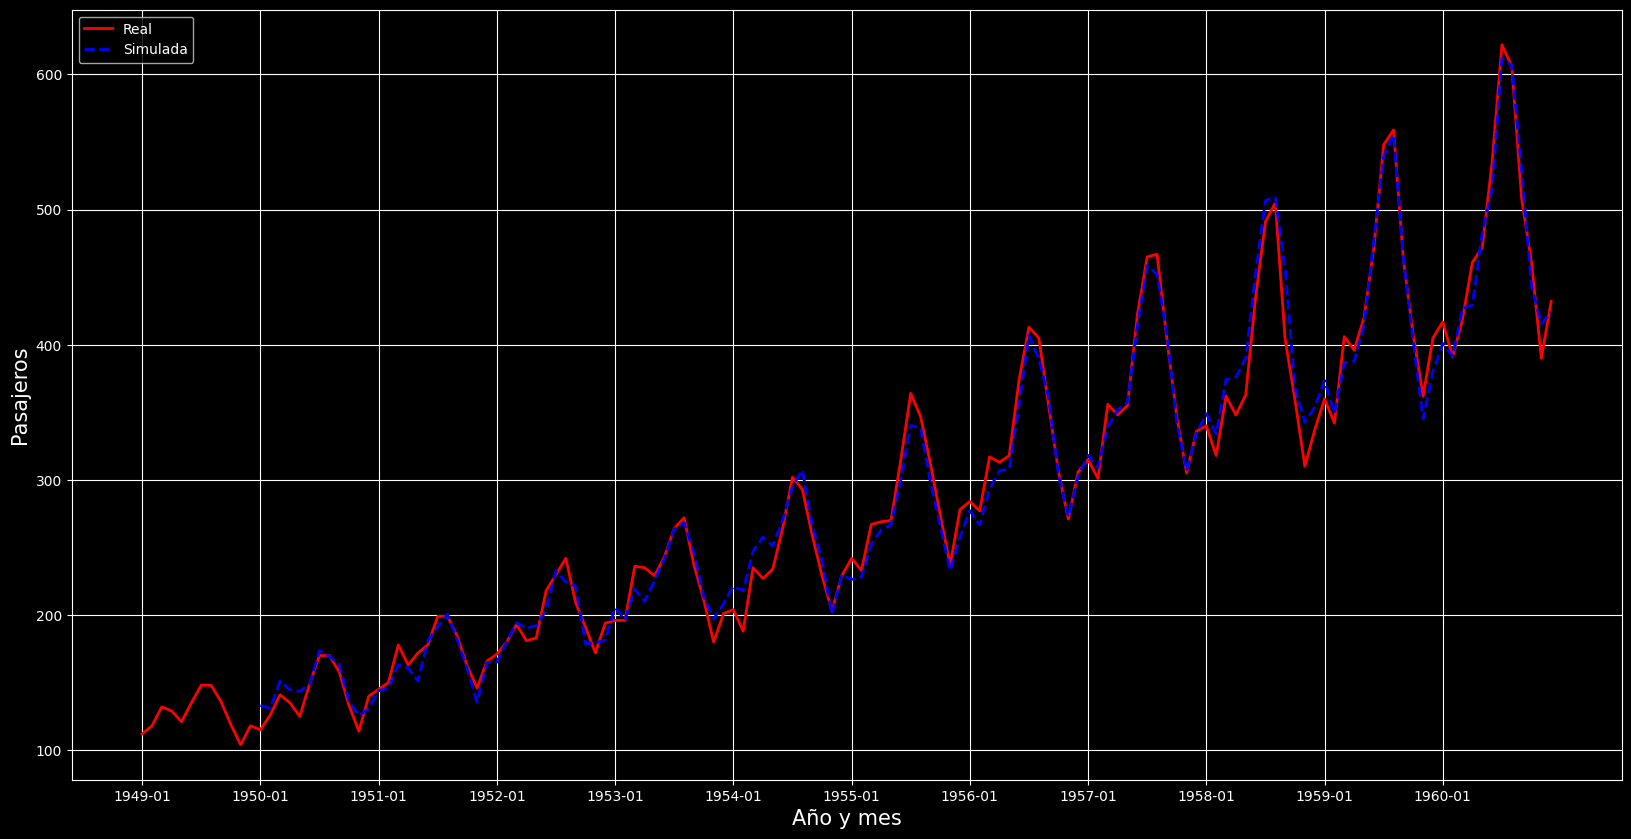

In [70]:

regressor = LinearRegression()

regressor.fit(passengers_windowed_m, passengers_raw[12:])

print(regressor.params_)

passengers_estimated = regressor.predict(passengers_windowed_m)

print(f"Error cuadrático medio: {regressor.mean_squared_error(passengers_windowed_m, passengers_raw[12:])}")


plt.figure(figsize = (20,10))
plt.plot(months_raw, passengers_raw, linewidth = 2, color = 'red', label = 'Real')
plt.plot(months_raw[12:], passengers_estimated, linewidth = 2, color = 'blue', linestyle = '--', label = 'Simulada')
plt.legend(loc = 'upper left')
plt.grid(True)
plt.xticks(months_raw[::12])
plt.xlabel("Año y mes", fontsize = 15)
plt.ylabel("Pasajeros", fontsize = 15)
plt.show()


Observando el gráfico de la curva simulada superpuesta a la real se puede observar alta similitud, lo cual se encuentra respaldado por el error cuadrático medio. Otro aspecto a destacar es que los datos simulados arrancan recíen en el segundo año, ya que por el modelo utilizado y el tamaño de ventana, para simular un mes se necesitan los datos de los doce anteriores.

Si bien las muestras utilizadas no son independientes, al tratarse de un proceso ergodico, ya que resulta estacionario y la media temporal es igual a la media de conjuntos, entonces se puede decir que bajo la ley de los grandes numeros:
$$\frac{1}{n}\sum^n_{i = 0}{x_i}$$
converge en probabilidad a la esperanza

**Predicción a futuro**:

Para predecir lo que va a suceder en los próximos treinta meses se utilizan los parametros de $\boldsymbol{W}$ ajustados con la funcion fit() y los ultimos doce meses de los que se tiene información. Luego el mes predecido se agrega a los meses conocidos para predecir el siguiente, se repite el proceso hasta llegar a la cantidad de meses deseada. Este método es autorregresivo, ya que se están usando las mismas salidas del predictor para predecir meses siguientes.

In [71]:
def predict_autorreg(x, n):
    out = regressor.predict(x)
    for i in range(n):
        temp = np.append(out, [regressor.predict(out[-12:])], axis=0)
        out = temp
    return out

In [72]:
def generate_months(start_year, amount):
    current_year = start_year
    current_month = 1
    months = []
    for i in range(amount):
        months.append("%d-%02d" % (current_year, current_month))
        if current_month == 12:
            current_year += 1
            current_month = 1
        else:
            current_month += 1
    return months

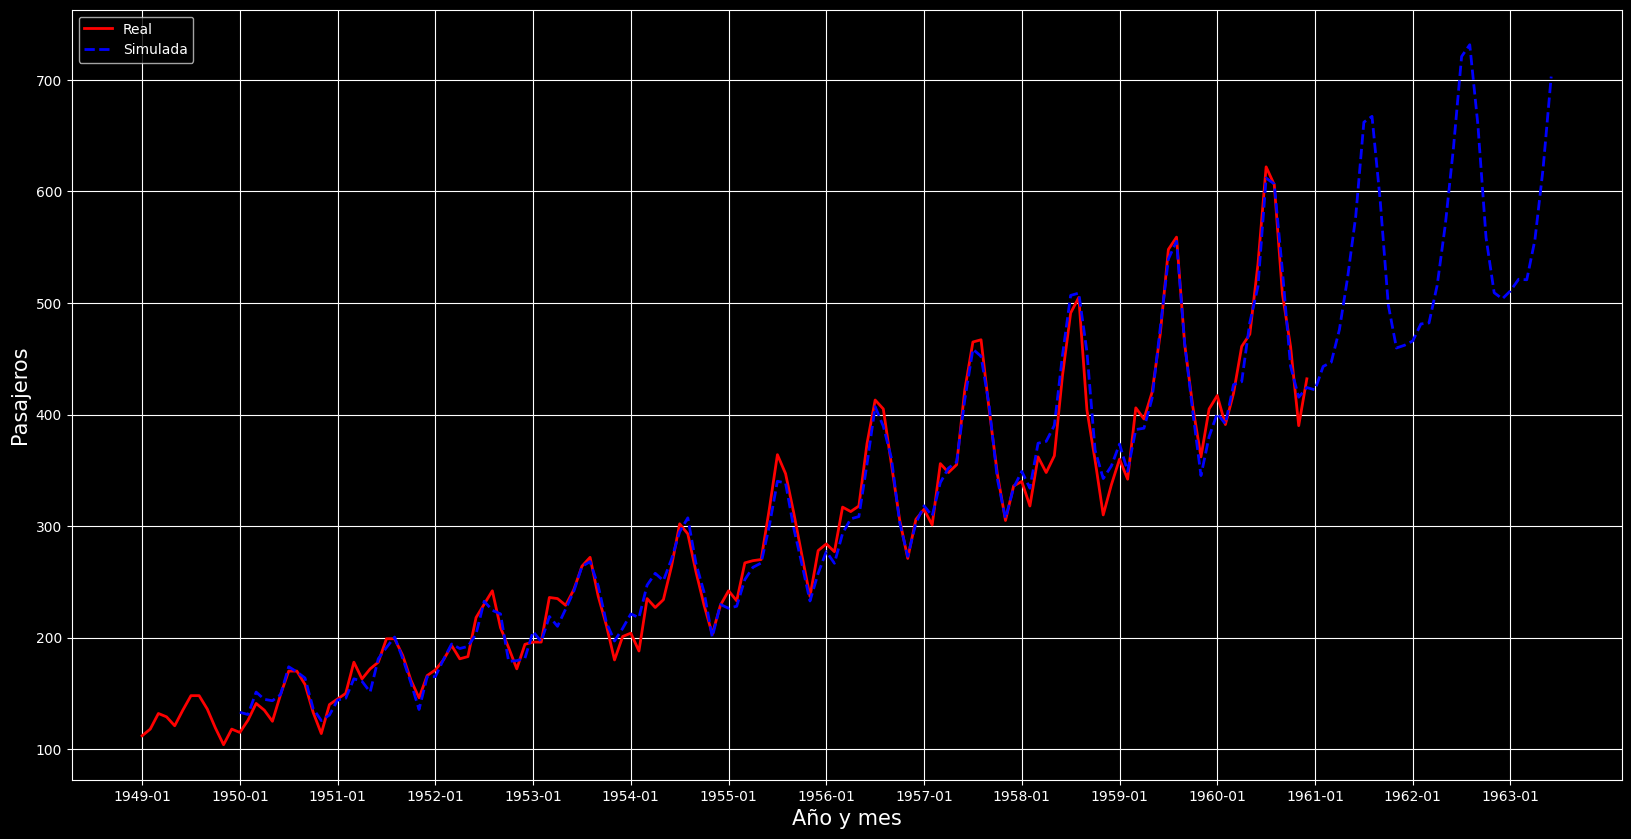

In [73]:

passengers_extended = predict_autorreg(passengers_windowed_m, 30)

months_extended = generate_months(1949, 174)

plt.figure(figsize = (20,10))
plt.plot(months_raw, passengers_raw, linewidth = 2, color = 'red', label = 'Real')
plt.plot(months_extended[12:], passengers_extended, linewidth = 2, color = 'blue', linestyle = '--', label = 'Simulada')
plt.legend(loc = 'upper left')
plt.grid(True)
plt.xticks(months_extended[::12])
plt.xlabel("Año y mes", fontsize = 15)
plt.ylabel("Pasajeros", fontsize = 15)
plt.show()

En el gráfico se puede apreciar como la predicción resulta coherente con la forma de la curva conocida, nuevamente presenta los picos en la misma etapa del año, correspondiente al verano del hemisferio norte. Además el crecimiento de los puntos más bajos del año parecería seguir la tendencia de los datos conocidos.

**Gradiente Descendiente**

Para este metodo, como bien indica su nombre, se busca minimizar el gradiente de la funcion $J(\theta)$. Para esto, primero se busca la expresión del gradiente:

$$ J(\boldsymbol{W}) = \frac{1}{n}(\boldsymbol{W}^T\boldsymbol{X}^T\boldsymbol{X}\boldsymbol{W}-2\boldsymbol{Y}^T\boldsymbol{X}\boldsymbol{W} + \boldsymbol{Y}^T\boldsymbol{Y})$$

Se busca $\nabla_W (J(W))$

Para esto se sabe que $\nabla(x^TBx) = (B + B^T)x$, entonces:

$$\nabla(\boldsymbol{W}^T\boldsymbol{X}^T\boldsymbol{X}\boldsymbol{W}) = (\boldsymbol{X}^T\boldsymbol{X} + (\boldsymbol{X}^T\boldsymbol{X})^T)\boldsymbol{W} = 2\boldsymbol{X}^T\boldsymbol{X}\boldsymbol{W} $$

Tambien se sabe que $\nabla(a^TX) = a$, entonces:

$$\nabla(2\boldsymbol{Y}^T\boldsymbol{X}\boldsymbol{W}) = (2\boldsymbol{Y}^T\boldsymbol{X})^T = 2\boldsymbol{X}^T\boldsymbol{Y}$$

Por ultimo, el gradiente buscado resulta:

$$\nabla_W (J(W)) = \frac{1}{n}(2\boldsymbol{X}^T\boldsymbol{X}\boldsymbol{W} - 2\boldsymbol{X}^T\boldsymbol{Y}) = \frac{2\boldsymbol{X}^T}{n}(\boldsymbol{X}\boldsymbol{W} - \boldsymbol{Y})$$

Finalmente, para obtener los valores de $\boldsymbol{W}$ se utiliza:

$$\boldsymbol{W}_{t+1} = \boldsymbol{W}_t - \alpha \nabla (J(\boldsymbol{W}_t))$$

Donde $\alpha$ es el $\textit{learning rate}$ y define el tiempo de convergencia del algoritmo. Se considerará que el algoritmo convirgió cuando el error cuadrático medio de actualización es menor a $\textit{tiny}$ de la librería numpy. El $\textit{learning rate}$ se eligió de forma empirica, buscando el valor más grande que permita la convergencia. Además, para mejorar los tiempos de convergencia y, lo que es equivalente, la cantidad de iteraciones hasta la convergencia se normalizó la entrada, restandole la media y dividiendola por el desvío estandar. 

In [74]:
class LinearRegression:
    def __init__(self):
        self.params_ = np.empty(13, dtype=np.float64)
        self.iteraciones = 0

    def fit(self, X, y):
        x_ext = np.insert(X, 0, 1, axis = 1)
        self.params_ = np.linalg.pinv(x_ext) @ y
        return

    def predict(self, X):
        if X.shape[0] == 12:
            x_ext = np.insert(X, 0, 1, axis = 0)
        else:
            x_ext = np.insert(X, 0, 1, axis = 1)
        return x_ext @ self.params_

    def mean_squared_error(self, X, y):
        x_ext = np.insert(X, 0, 1, axis = 1)
        temp = x_ext @ self.params_ - y
        return np.mean(temp**2)

    def fit_gradient(self, X, y, learning_rate):
        self.params_ = np.ones(X.shape[1]+1)
        x_ext = np.insert(X, 0, 1, axis = 1)
        error = 1
        while error > np.finfo(np.float64).tiny:
            gradient = (2/len(x_ext))*(x_ext.T @ (x_ext @ self.params_ - y))
            params = self.params_ -learning_rate*gradient
            error = np.mean((params - self.params_)**2)
            self.params_ = params
            self.iteraciones += 1
        print(f"Iteraciones hasta convergencia {self.iteraciones}")




In [75]:
regressor = LinearRegression()

passenger_normalized = (passengers_windowed_m - np.mean(passengers_windowed_m, axis = 0))/np.std(passengers_windowed_m, axis = 0)

regressor.fit_gradient(passenger_normalized, passengers_raw[12:], learning_rate = 0.095)

print(regressor.params_)

Iteraciones hasta convergencia 64727
[294.26515152  65.07987415  33.77879112 -26.80932393  29.65756227
 -28.68890997  19.21843886 -21.6218855   26.26352289 -24.83107069
  22.58740766 -31.56807759  51.21047742]


Error cuadrático medio: 182.53756005860734


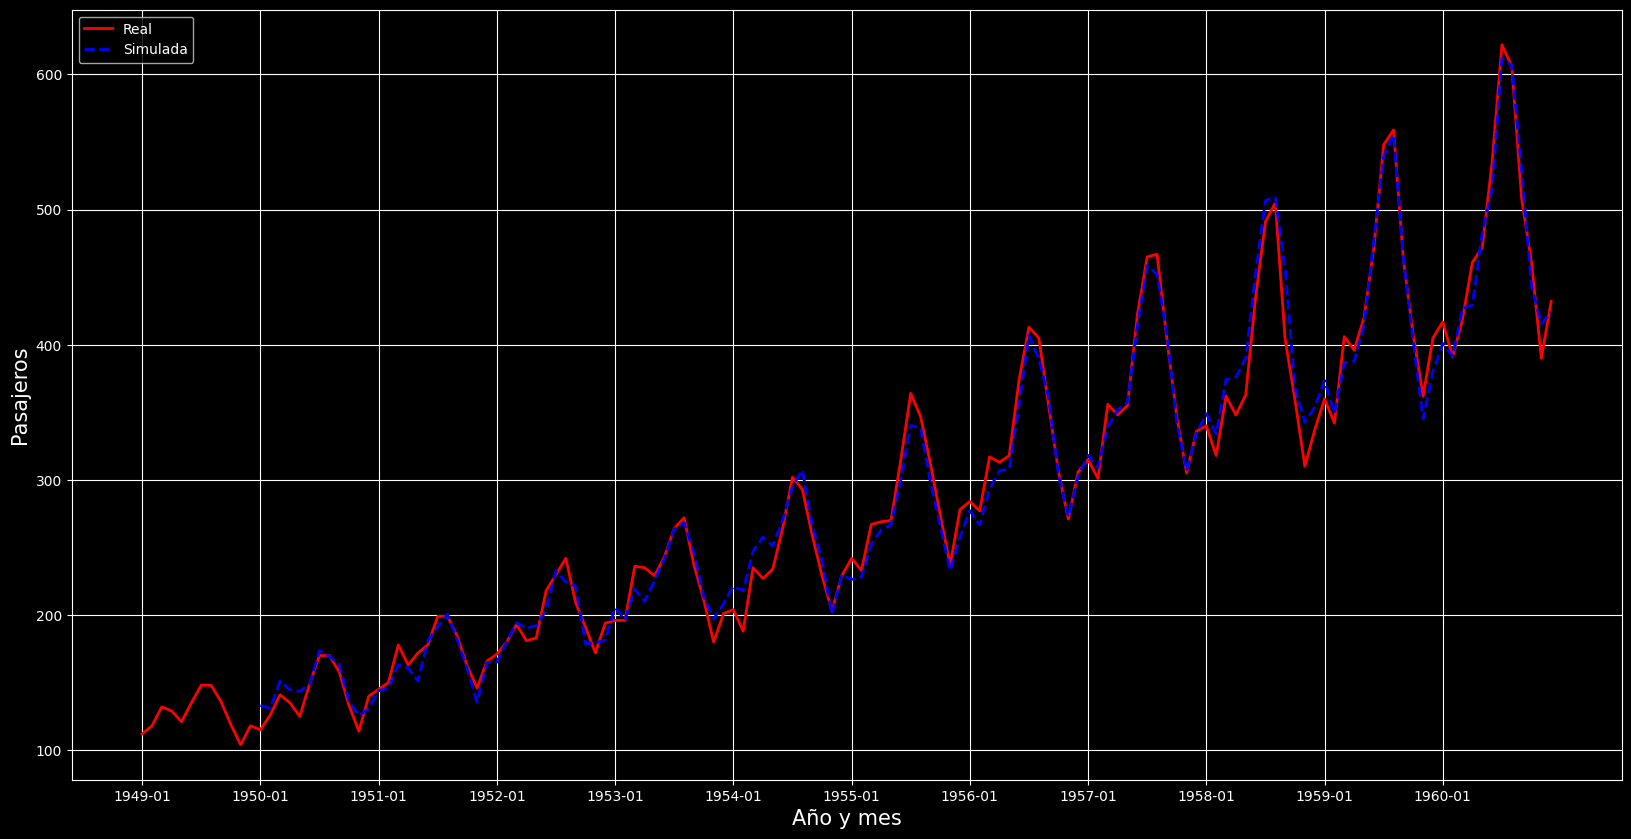

In [76]:
passengers_estimated_gradient = regressor.predict(passenger_normalized)

print(f"Error cuadrático medio: {regressor.mean_squared_error(passenger_normalized, passengers_raw[12:])}")

plt.figure(figsize = (20,10))
plt.plot(months_raw, passengers_raw, linewidth = 2, color = 'red', label = 'Real')
plt.plot(months_raw[12:], passengers_estimated_gradient, linewidth = 2, color = 'blue', linestyle = '--', label = 'Simulada')
plt.legend(loc = 'upper left')
plt.grid(True)
plt.xticks(months_raw[::12])
plt.xlabel("Año y mes", fontsize = 15)
plt.ylabel("Pasajeros", fontsize = 15)
plt.show()

Observando el gráfico resulta muy dificil encontrar diferencias con el de la predicción de parametros obtenidos a través de la pseudoinversa, pero observando el error cuadratico medio de predicción se puede apreciar que estos difieren recién en la cifra de magnitud $10^{-13}$ lo que se corresponde con la casi nula diferencia apreciable en los gráficos.


In [77]:
def predict_autorreg_norm(x, n, mean, std):
    out = regressor.predict((x-mean)/std)
    for i in range(n):
        temp = np.append(out, [regressor.predict(((out[-12:]) - mean) / std)], axis=0)
        out = temp
    return out

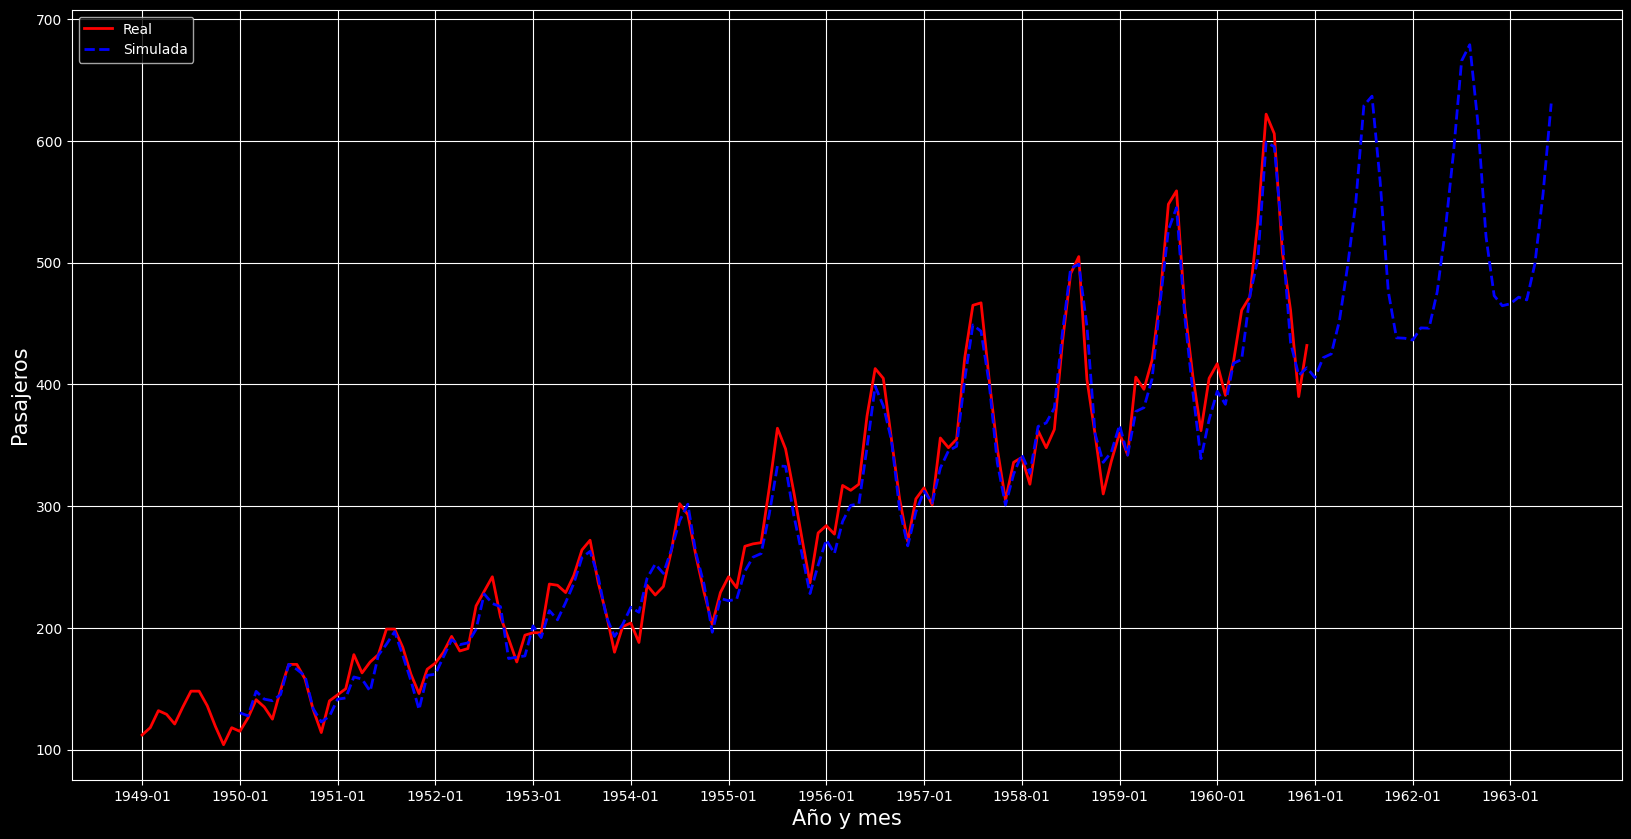

In [78]:
passengers_extended = predict_autorreg_norm(passengers_windowed_m, 30, np.mean(passengers_windowed_m), np.std(passengers_windowed_m))

months_extended = generate_months(1949, 174)

plt.figure(figsize = (20,10))
plt.plot(months_raw, passengers_raw, linewidth = 2, color = 'red', label = 'Real')
plt.plot(months_extended[12:], passengers_extended, linewidth = 2, color = 'blue', linestyle = '--', label = 'Simulada')
plt.legend(loc = 'upper left')
plt.grid(True)
plt.grid(True)
plt.xticks(months_extended[::12])
plt.xlabel("Año y mes", fontsize = 15)
plt.ylabel("Pasajeros", fontsize = 15)
plt.show()

Nuevamnte, como los parámetros obtenidos con el gradiente descendiente son tan similares a los obtenidos con la psudoinversa, la predicción es prácticamente igual y se pueden hacer las mismas observaciones hechas en el primer caso
